In [1]:
!pip install mplsoccer
!pip install networkx
import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 2.9 MB/s eta 0:00:00


In [2]:
import xml.etree.ElementTree as et
from IPython.core import display as ICD
from pandas import json_normalize
import pandas as pd
from tqdm.notebook import tqdm
import os
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
from datetime import datetime
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer.pitch import Pitch
import networkx as nx

#@title
types_dict={1:"Pass",2:"Offside Pass",3:"Take On",4:"Foul",5:"Out",6:"Corner Awarded",7:"Tackle",8:"Interception",9:"Turnover",10:"Save",11:"Claim",12:"Clearance",13:"Miss",14:"Post",15:"Attempt Saved",16:"Goal",17:"Card",18:"Player off",19:"Player on",20:"Player retired",21:"Player returns",22:"Player becomes goalkeeper",23:"Goalkeeper becomes player",24:"Condition change",25:"Official change",27:"Start delay",28:"End delay",30:"End",31:"Picked an orange",32:"Start",34:"Team set up",35:"Player changed position",36:"Player changed Jersey number",37:"Collection End",38:"Temp_Goal",39:"Temp_Attempt",40:"Formation change",41:"Punch",42:"Good Skill",43:"Deleted event",44:"Aerial",45:"Challenge",47:"Rescinded card",49:"Ball recovery",50:"Dispossessed",51:"Error",52:"Keeper pick-up",53:"Cross not claimed",54:"Smother",55:"Offside provoked",56:"Shield ball opp",57:"Foul throw-in",58:"Penalty faced",59:"Keeper Sweeper",60:"Chance missed",61:"Ball touch",63:"Temp_Save",64:"Resume",65:"Contentious referee decision",67:"50/50",68:"Referee drop ball",69:"Failed To Block",72:"Caught offside",73:"Other Ball Contact",74:"Blocked pass"};
types = pd.DataFrame.from_dict(types_dict,orient='index').reset_index()
types.columns=["type_id","event_name"]

qualifiers_dict={1:"Long ball",2:"Cross",3:"Head pass",4:"Through ball",5:"Free kick taken",6:"Corner taken",7:"Players caught offside",8:"Goal disallowed",9:"Penalty",10:"Hand",11:"6-seconds violation",12:"Dangerous play",13:"Foul",14:"Last line",15:"Head",16:"Small box-centre",17:"Box-centre",18:"Out of box-centre",19:"35+ centre",20:"Right footed",21:"Other body part",22:"Regular play",23:"Fast break",24:"Set piece",25:"From corner",26:"Free kick",28:"Own goal",29:"Assisted",30:"Involved",31:"Yellow Card",32:"Second yellow",33:"Red card",34:"Referee abuse",35:"Argument",36:"Fight",37:"Time wasting",38:"Excessive celebration",39:"Crowd interaction",40:"Other reason",41:"Injury",42:"Tactical",44:"Player position",49:"Attendance figure",50:"Official position",51:"Official ID",53:"Injured player id",54:"End cause",55:"Related event ID",56:"Zone",57:"End type",59:"Jersey number",60:"Small box-right",61:"Small box-left",62:"Box-deep right",63:"Box-right",64:"Box-left",65:"Box-deep left",66:"Out of box-deep right",67:"Out of box-right",68:"Out of box-left",69:"Out of box-deep left",70:"35+ right",71:"35+ left",72:"Left footed",73:"Left",74:"High",75:"Right",76:"Low left",77:"High left",78:"Low centre",79:"High centre",80:"Low right",81:"High right",82:"Blocked",83:"Close left",84:"Close right",85:"Close high",86:"Close left and high",87:"Close right and high",88:"High claim",89:"1 on 1",90:"Deflected save",91:"Dive and deflect",92:"Catch",93:"Dive and catch",94:"Def block",95:"Back pass",96:"Corner situation",97:"Direct free",100:"Six yard blocked",101:"Saved off line",102:"Goal mouth y co-ordinate",103:"Goal mouth z co-ordinate",106:"Attacking Pass",107:"Throw-in",108:"Volley",109:"Overhead",110:"Half Volley",111:"Diving Header",112:"Scramble",113:"Strong",114:"Weak",115:"Rising",116:"Dipping",117:"Lob",118:"One Bounce",119:"Few Bounces",120:"Swerve Left",121:"Swerve Right",122:"Swerve Moving",123:"Keeper Throw",124:"Goal Kick",127:"Direction of play",128:"Punch",130:"Team formation",131:"Team player formation",132:"Dive",133:"Deflection",134:"Far Wide Left",135:"Far Wide Right",136:"Keeper Touched",137:"Keeper Saved",138:"Hit Woodwork",139:"Own Player",140:"Pass End X",141:"Pass End Y",144:"Deleted event type",145:"Formation slot",146:"Blocked x co-ordinate",147:"Blocked y co-ordinate",153:"Not past goal line",154:"Intentional assist",155:"Chipped",156:"Lay-off",157:"Launch",158:"Persistent infringement",159:"Foul and abusive language",160:"Throw-in set piece",161:"Encroachment",162:"Leaving field",163:"Entering field",164:"Spitting",165:"Professional foul",166:"Handling on the line",167:"Out of play",168:"Flick-on",169:"Leading to attempt",170:"Leading to goal",171:"Rescinded card",172:"No impact on timing",173:"Parried safe",174:"Parried danger",175:"Fingertip",176:"Caught",177:"Collected",178:"Standing",179:"Diving",180:"Stooping",181:"Reaching",182:"Hands",183:"Feet",184:"Dissent",185:"Blocked cross",186:"Scored",187:"Saved",188:"Missed",189:"Player not visible",190:"From shot off target",191:"Off the ball foul",192:"Block by hand",194:"Captain",195:"Pull Back",196:"Switch of play",197:"Team kit",198:"GK hoof",199:"Gk kick from hands",200:"Referee stop",201:"Referee delay",202:"Weather problem",203:"Crowd trouble",204:"Fire",205:"Object thrown on pitch",206:"Spectator on pitch",207:"Awaiting officials decision",208:"Referee Injury",209:"Game end",210:"Assist",211:"Overrun",212:"Length",213:"Angle",214:"Big Chance",215:"Individual Play",216:"2nd related event ID",217:"2nd assisted",218:"2nd assist",219:"Players on both posts",220:"Player on near post",221:"Player on far post",222:"No players on posts",223:"In-swinger",224:"Out-swinger",225:"Straight",226:"Suspended",227:"Resume",228:"Own shot blocked",229:"Post-match complete",230:"GK X Coordinate",231:"GK Y Coordinate",232:"Unchallenged"};
qualifiers = pd.DataFrame.from_dict(qualifiers_dict,orient='index').reset_index()
qualifiers.columns = ["qualifier_id","description"]

qualifiers_dict2 = {str(key): str(value) for key, value in qualifiers_dict.items()}


def parsef24_folder(F24folder):
  games_list = []
  events_list = []

  for file in tqdm(os.listdir(F24folder)):
    if file.endswith(".xml"):
      file_path = os.path.join(F24folder, file)
      #print(f"Processing: {file_path}")

      tree = et.ElementTree(file=file_path)
      games = tree.getroot()
      gameinfo = games.findall('Game')[0]  # Assuming there's always one 'Game' element

      # Cache game metadata
      game_id = gameinfo.get('id')
      game_meta = {
          "game_id": game_id,
          "home_team_id": gameinfo.get('home_team_id'),
          "home_team_name": gameinfo.get('home_team_name'),
          "away_team_id": gameinfo.get('away_team_id'),
          "away_team_name": gameinfo.get('away_team_name'),
          "competition_id": gameinfo.get('competition_id'),
          "competition_name": gameinfo.get('competition_name'),
          "season_id": gameinfo.get('season_id'),
      }
      games_list.append(game_meta)

      for game in games:
        for event in game:
          # Build a dictionary for the event data
          event_data = event.attrib.copy()
          # Use list comprehension to extract qualifiers
          event_data["qualifiers"] = [q.attrib for q in event]
          event_data["game_id"] = game_id  # Attach game metadata to event
          # Build a DataFrame for this event and append it to the list
          events_list.append(event_data)

  # Concatenate all parsed events into a single DataFrame
  game_df = pd.DataFrame(games_list)
  match_events = pd.DataFrame(events_list)

  match_events[["id","event_id","type_id","period_id","min","sec"]] = match_events[["id","event_id","type_id","period_id","min","sec"]].astype(int)
  match_events[["y","x"]] = match_events[["y","x"]].astype(float)
  match_events = pd.merge(match_events,types, on="type_id", how = "left")
  match_events = match_events[ ['id',"event_id","type_id", "event_name" ]+ [ col for col in match_events.columns if col not in ['id',"event_id","type_id", "event_name" ] ] ]

  # add game info to match_events
  match_events = pd.merge(match_events, game_df, on="game_id", how="inner")
  return match_events


def explode_event(nome_df, id_evento, mytresh):
    # Filter the dataframe for the required event type
    nome_df = nome_df[nome_df["type_id"] == id_evento].copy()

    if nome_df.empty:
        return pd.DataFrame()  # Return empty if no matching events

    # Explode 'qualifiers' column (assuming it's a list of dictionaries)
    nome_df_exploded = nome_df.explode("qualifiers")

    # Normalize the qualifiers column
    qualifiers_df = pd.json_normalize(nome_df_exploded["qualifiers"]).fillna("yes")

    # Add the event ID back to qualifiers_df
    qualifiers_df["id"] = nome_df_exploded["id"].values

    # pivot table
    qualifiers_df = qualifiers_df\
      .pivot_table(index='id', columns='qualifier_id', values='value', aggfunc='first')\
      .reset_index()

    # Rename columns based on your dictionary
    qualifiers_df.rename(columns=qualifiers_dict2, inplace=True)

    # Drop columns that have too many NaN values
    min_non_na = len(qualifiers_df) * mytresh
    qualifiers_df = qualifiers_df.dropna(thresh=min_non_na, axis=1)

    # Drop the original exploded 'qualifiers' column
    nome_df = nome_df.drop(columns=["qualifiers"])

    # Merge back
    exploded_df = nome_df.merge(qualifiers_df, on="id", how="outer").fillna("-")

    return exploded_df

In [3]:
all_match_events = parsef24_folder('/content/drive/MyDrive/Opta Data')

  0%|          | 0/301 [00:00<?, ?it/s]

In [4]:
### Define um DataFrame com os game events para uma determinada equipa, num determinado jogo
def build_team_game_events(team_id, game_id, match_events = all_match_events,file = '/content/drive/MyDrive/opta_planteis_portugal.xlsx'):
  match_events_game_df = match_events[match_events['game_id'] == game_id]
  match_events_team_df = match_events_game_df[match_events_game_df['team_id']==team_id][match_events_game_df['event_name']!='Deleted event'].reset_index(drop=True)

  planteis = pd.read_excel(file)
  planteis['player_id'] = planteis['player_id'].astype(str)
  dict_planteis = dict(zip(planteis['player_id'], planteis['player_name']))
  match_events_team_df['player_name'] = match_events_team_df['player_id'].map(dict_planteis)

  for index, row in match_events_team_df.iterrows():
    if (row['type_id']==1) and (row['outcome']=='1'):
      match_events_team_df.at[index, 'receiver_id'] = match_events_team_df.at[index+1,'player_id']
    else:
      match_events_team_df.at[index, 'receiver_id'] = '-'
      match_events_team_df['receiver_name'] = "-"
  match_events_team_df['receiver_name'] = match_events_team_df['receiver_id'].map(dict_planteis)

  list_sub_indexes = [index for index, row in match_events_team_df.iterrows() if row['event_name']=='Player off']
  first_sub_index = list_sub_indexes[0]
  match_events_team_substitution = match_events_team_df.truncate(after = first_sub_index)
  return match_events_team_substitution

### Define um DataFrame com os passes bem sucedidos para a equipa anterior, no jogo anterior
def build_passing_df(match_events_team_df):
  exploded_df = explode_event(match_events_team_df, 1, 0.15)
  pass_df = exploded_df[['id','event_id','team_id','player_id','player_name','outcome','x','y','receiver_id','receiver_name','Pass End X','Pass End Y']]
  team_pass_df = pass_df[pass_df['outcome']=='1']
  team_pass_df['x'] = team_pass_df['x'].astype(float)
  team_pass_df['y'] = team_pass_df['y'].astype(float)
  team_pass_df['Pass End X'] = team_pass_df['Pass End X'].astype(float)
  team_pass_df['Pass End Y'] = team_pass_df['Pass End Y'].astype(float)
  return team_pass_df

### Cria um DataFrame com os passes entre os jogadores da equipa e valores médios de posição de passes dos jogadores
def compute_passes_between(df):

  average_locations = df.groupby('player_name').agg({'x':['mean'],'y':['mean','count']})
  average_locations.columns = ['x_mean', 'y_mean', 'count']

  pass_between = df.groupby(['player_name', 'receiver_name']).id.count().reset_index()
  pass_between.rename({'id':'pass_count'},axis='columns',inplace=True)

  pass_between = pass_between.merge(average_locations, left_on='player_name', right_index=True)
  pass_between = pass_between.merge(average_locations, left_on='receiver_name', right_index=True,suffixes=['','_end'])

  return pass_between

### Cria um DataFrame com as medidas de centralidade de todos os jogadores de uma determinada equipa
def compute_mean_centrality_without_eigenvector(df):

  team_pass = build_passing_df(df)
  pass_between = compute_passes_between(team_pass)

  G = nx.DiGraph()
  G.add_edges_from(list(zip(pass_between['player_name'].to_list(),pass_between['receiver_name'].to_list())),weight=pass_between['pass_count'])

  centrality_df =pd.DataFrame()
  metrics = [nx.in_degree_centrality(G),nx.out_degree_centrality(G), nx.closeness_centrality(G),nx.betweenness_centrality(G)]

  for i, metric in enumerate(metrics):
    for key, value in metric.items():
      centrality_df.at[key, 'centrality'+str(i)] = value
    for key_ in team_pass['player_name'].unique():
      if key_ not in metric.keys():
        centrality_df.at[key_, 'centrality'+str(i)] = 0
  centrality_df = centrality_df.rename(columns={"centrality0": "in_Degree", "centrality1": "out_Degree", "centrality2": "Closeness", "centrality3": "Betweenness"})

  return centrality_df

### Cria um dicionário com a medida de centralidade escolhida, para cada jogador titular de uma determinada equipa, num determinado jogo
def mean_rank_centralities_without_eigenvector(team,game):
  events = build_team_game_events(team_id = team, game_id = game)
  passing_df = build_passing_df(events)
  centrality_df = compute_mean_centrality_without_eigenvector(events)
  rank_centrality_df = pd.DataFrame()
  rank_centrality_df['Rank_in_Degree'] = centrality_df['in_Degree'].rank(ascending=False)
  rank_centrality_df['Rank_out_Degree'] = centrality_df['out_Degree'].rank(ascending=False)
  rank_centrality_df['Rank_Closeness'] = centrality_df['Closeness'].rank(ascending=False)
  rank_centrality_df['Rank_Betweenness'] = centrality_df['Betweenness'].rank(ascending=False)
  rank_centrality_df['mean_rank_centrality'] = rank_centrality_df.mean(axis=1)
  rank_centrality = rank_centrality_df.sort_values(by='mean_rank_centrality')
  dict_centralities={}
  for id in rank_centrality.index:
    dict_centralities[id]= [rank_centrality_df.loc[id,'mean_rank_centrality']]
  return dict_centralities


### Define a rede de passes anterior e representa-a
def visualize_pass_network_without_eigenvector(team_id, game_id):
  match_events_team_ = build_team_game_events(team_id, game_id)
  team_pass_ = build_passing_df(match_events_team_)
  pass_between_ = compute_passes_between(team_pass_)
  dict_rank_centralities = mean_rank_centralities_without_eigenvector(team_id, game_id)

  list_nodes = list(team_pass_['player_name'].unique())
  list_edges = [(row['player_name'], row['receiver_name'], row['pass_count']) for index, row in pass_between_.iterrows()]
  pos={}
  for index, row in pass_between_.iterrows():
    pos[row['player_name']] = (row['x_mean'], row['y_mean'])

  G = nx.DiGraph()
  G.add_nodes_from(list_nodes)
  G.add_weighted_edges_from(list_edges)

  for node in G.nodes():
    G.nodes[node]['centrality'] = dict_rank_centralities[node][0]

  pitch = Pitch(pitch_type='opta',pitch_color='grass', line_color='white', stripe=True)
  fig, ax = pitch.draw(figsize=(16, 11))

  node_sizes = [1000/dict_rank_centralities[node][0] for node in G.nodes()]
  edge_widths = [row['pass_count'] for index, row in pass_between.iterrows()]

  edge_colors = pass_between_['pass_count']

  cmap = plt.cm.plasma

  nodes = nx.draw_networkx_nodes(G, pos=pos, node_size=node_sizes, node_color="r")
  edges = nx.draw_networkx_edges(G,pos=pos,node_size=node_sizes,arrowstyle="->",arrowsize=10,edge_color=edge_colors,edge_cmap=cmap, width=edge_widths, alpha=0.3)

  nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")

  pc = mpl.collections.PatchCollection(edges, cmap=cmap)
  pc.set_array(edge_colors)
  ax.add_collection(pc)
  plt.colorbar(pc,ax=ax)
  plt.show()
  return

### Cria um dicionário com a medida de centralidade escolhida, para todos os jogos, de uma determinada equipa
def mean_rank_centralities_all_matches_without_eigenvector(team):
  dict_centralities_all_matches={}
  for game in all_match_events[all_match_events['team_id']==team]['game_id'].unique():
    events = build_team_game_events(team_id = team, game_id = game)
    passing_df = build_passing_df(events)
    centrality_df = compute_mean_centrality_without_eigenvector(events)
    rank_centrality_df = pd.DataFrame()
    rank_centrality_df['Rank_in_Degree'] = centrality_df['in_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_out_Degree'] = centrality_df['out_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_Closeness'] = centrality_df['Closeness'].rank(ascending=False)
    rank_centrality_df['Rank_Betweenness'] = centrality_df['Betweenness'].rank(ascending=False)
    rank_centrality_df['mean_rank_centrality'] = rank_centrality_df.mean(axis=1)
    for id in rank_centrality_df.index:
      if id in dict_centralities_all_matches.keys():
        dict_centralities_all_matches[id].append(rank_centrality_df.loc[id,'mean_rank_centrality'])
      else:
        dict_centralities_all_matches[id] = [rank_centrality_df.loc[id,'mean_rank_centrality']]
  return dict_centralities_all_matches

### Define o dicionário final, contendo a média da medida de centralidade selecionada, para cada jogador, em todos os jogos da época
def mean_rank_centrality_season(dict_):
  dict_mean_centralities_final = {}
  for key,value in dict_.items():
    if len(value)>=10:
      dict_mean_centralities_final[key] = np.mean(value)
  return dict(sorted(dict_mean_centralities_final.items(), key=lambda item: item[1]))

### Cria um dicionário com a medida de centralidade escolhida, para todos os jogos, em casa de uma determinada equipa
def mean_rank_centralities_all_home_matches_without_eigenvector(team):
  dict_centralities_all_matches={}
  for game in all_match_events[(all_match_events['team_id']==team) & (all_match_events['home_team_id']==team)]['game_id'].unique():
    events = build_team_game_events(team_id = team, game_id = game)
    passing_df = build_passing_df(events)
    centrality_df = compute_mean_centrality_without_eigenvector(events)
    rank_centrality_df = pd.DataFrame()
    rank_centrality_df['Rank_in_Degree'] = centrality_df['in_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_out_Degree'] = centrality_df['out_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_Closeness'] = centrality_df['Closeness'].rank(ascending=False)
    rank_centrality_df['Rank_Betweenness'] = centrality_df['Betweenness'].rank(ascending=False)
    rank_centrality_df['mean_rank_centrality'] = rank_centrality_df.mean(axis=1)
    for id in rank_centrality_df.index:
      if id in dict_centralities_all_matches.keys():
        dict_centralities_all_matches[id].append(rank_centrality_df.loc[id,'mean_rank_centrality'])
      else:
        dict_centralities_all_matches[id] = [rank_centrality_df.loc[id,'mean_rank_centrality']]
  return dict_centralities_all_matches


### Define o dicionário final, contendo a média da medida de centralidade selecionada, para cada jogador, em todos os jogos da época
def mean_rank_centrality_season_home(dict_):
  dict_mean_centralities_final = {}
  for key,value in dict_.items():
    if len(value)>=5:
      dict_mean_centralities_final[key] = np.mean(value)
  return dict(sorted(dict_mean_centralities_final.items(), key=lambda item: item[1]))

### Cria um dicionário com a medida de centralidade escolhida, para todos os jogos, em casa de uma determinada equipa
def mean_rank_centralities_all_away_matches_without_eigenvector(team):
  dict_centralities_all_matches={}
  for game in all_match_events[(all_match_events['team_id']==team) & (all_match_events['away_team_id']==team)]['game_id'].unique():
    events = build_team_game_events(team_id = team, game_id = game)
    passing_df = build_passing_df(events)
    centrality_df = compute_mean_centrality_without_eigenvector(events)
    rank_centrality_df = pd.DataFrame()
    rank_centrality_df['Rank_in_Degree'] = centrality_df['in_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_out_Degree'] = centrality_df['out_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_Closeness'] = centrality_df['Closeness'].rank(ascending=False)
    rank_centrality_df['Rank_Betweenness'] = centrality_df['Betweenness'].rank(ascending=False)
    rank_centrality_df['mean_rank_centrality'] = rank_centrality_df.mean(axis=1)
    for id in rank_centrality_df.index:
      if id in dict_centralities_all_matches.keys():
        dict_centralities_all_matches[id].append(rank_centrality_df.loc[id,'mean_rank_centrality'])
      else:
        dict_centralities_all_matches[id] = [rank_centrality_df.loc[id,'mean_rank_centrality']]
  return dict_centralities_all_matches



### Define o dicionário final, contendo a média da medida de centralidade selecionada, para cada jogador, em todos os jogos da época
def mean_rank_centrality_season_away(dict_):
  dict_mean_centralities_final = {}
  for key,value in dict_.items():
    if len(value)>=5:
      dict_mean_centralities_final[key] = np.mean(value)
  return dict(sorted(dict_mean_centralities_final.items(), key=lambda item: item[1]))

### Cria um dicionário com a medida de centralidade escolhida, para todos os jogos, em casa de uma determinada equipa
def mean_rank_centralities_all_top_matches_without_eigenvector(team):
  dict_centralities_all_matches={}
  for game in all_match_events[(all_match_events['team_id']==team) &  ( (all_match_events['home_team_id']==team) & (all_match_events['away_team_id'].isin(['201','251','255','372']) )) | ((all_match_events['away_team_id']==team) &  (all_match_events['home_team_id'].isin(['201','251','255','372'])) )]['game_id'].unique():
    events = build_team_game_events(team_id = team, game_id = game)
    passing_df = build_passing_df(events)
    centrality_df = compute_mean_centrality_without_eigenvector(events)
    rank_centrality_df = pd.DataFrame()
    rank_centrality_df['Rank_in_Degree'] = centrality_df['in_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_out_Degree'] = centrality_df['out_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_Closeness'] = centrality_df['Closeness'].rank(ascending=False)
    rank_centrality_df['Rank_Betweenness'] = centrality_df['Betweenness'].rank(ascending=False)
    rank_centrality_df['mean_rank_centrality'] = rank_centrality_df.mean(axis=1)
    for id in rank_centrality_df.index:
      if id in dict_centralities_all_matches.keys():
        dict_centralities_all_matches[id].append(rank_centrality_df.loc[id,'mean_rank_centrality'])
      else:
        dict_centralities_all_matches[id] = [rank_centrality_df.loc[id,'mean_rank_centrality']]
  return dict_centralities_all_matches


### Define o dicionário final, contendo a média da medida de centralidade selecionada, para cada jogador, em todos os jogos da época
def mean_rank_centrality_season_top(dict_):
  dict_mean_centralities_final = {}
  for key,value in dict_.items():
    if len(value)>=2:
      dict_mean_centralities_final[key] = np.mean(value)
  return dict(sorted(dict_mean_centralities_final.items(), key=lambda item: item[1]))


def compute_mean_centrality_without_eigenvector(df):

  team_pass = build_passing_df(df)
  pass_between = compute_passes_between(team_pass)

  G = nx.DiGraph()
  G.add_edges_from(list(zip(pass_between['player_name'].to_list(),pass_between['receiver_name'].to_list())),weight=pass_between['pass_count'])

  centrality_df =pd.DataFrame()
  metrics = [nx.in_degree_centrality(G),nx.out_degree_centrality(G), nx.closeness_centrality(G),nx.betweenness_centrality(G)]

  for i, metric in enumerate(metrics):
    for key, value in metric.items():
      centrality_df.at[key, 'centrality'+str(i)] = value
    for key_ in team_pass['player_name'].unique():
      if key_ not in metric.keys():
        centrality_df.at[key_, 'centrality'+str(i)] = 0
  centrality_df = centrality_df.rename(columns={"centrality0": "in_Degree", "centrality1": "out_Degree", "centrality2": "Closeness", "centrality3": "Betweenness"})

  return centrality_df

### Cria um dicionário com a medida de centralidade escolhida, para cada jogador titular de uma determinada equipa, num determinado jogo
def mean_rank_centralities_own_half(team,game):
  events = build_team_game_events(team_id = team, game_id = game)
  events = events[events['x']<50]
  passing_df = build_passing_df(events)
  centrality_df = compute_mean_centrality_without_eigenvector(events)
  rank_centrality_df = pd.DataFrame()
  rank_centrality_df['Rank_in_Degree'] = centrality_df['in_Degree'].rank(ascending=False)
  rank_centrality_df['Rank_out_Degree'] = centrality_df['out_Degree'].rank(ascending=False)
  rank_centrality_df['Rank_Closeness'] = centrality_df['Closeness'].rank(ascending=False)
  rank_centrality_df['Rank_Betweenness'] = centrality_df['Betweenness'].rank(ascending=False)
  rank_centrality_df['mean_rank_centrality'] = rank_centrality_df.mean(axis=1)
  rank_centrality = rank_centrality_df.sort_values(by='mean_rank_centrality')
  dict_centralities={}
  for id in rank_centrality.index:
    dict_centralities[id]= [rank_centrality_df.loc[id,'mean_rank_centrality']]
  return dict_centralities

### Cria um dicionário com a medida de centralidade escolhida, para todos os jogos, de uma determinada equipa
def mean_rank_centralities_all_matches_own_half(team):
  dict_centralities_all_matches={}
  for game in all_match_events[all_match_events['team_id']==team]['game_id'].unique():
    events = build_team_game_events(team_id = team, game_id = game)
    events = events[events['x']<50]
    passing_df = build_passing_df(events)
    centrality_df = compute_mean_centrality_without_eigenvector(events)
    rank_centrality_df = pd.DataFrame()
    rank_centrality_df['Rank_in_Degree'] = centrality_df['in_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_out_Degree'] = centrality_df['out_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_Closeness'] = centrality_df['Closeness'].rank(ascending=False)
    rank_centrality_df['Rank_Betweenness'] = centrality_df['Betweenness'].rank(ascending=False)
    rank_centrality_df['mean_rank_centrality'] = rank_centrality_df.mean(axis=1)
    for id in rank_centrality_df.index:
      if id in dict_centralities_all_matches.keys():
        dict_centralities_all_matches[id].append(rank_centrality_df.loc[id,'mean_rank_centrality'])
      else:
        dict_centralities_all_matches[id] = [rank_centrality_df.loc[id,'mean_rank_centrality']]
  return dict_centralities_all_matches


### Define o dicionário final, contendo a média da medida de centralidade selecionada, para cada jogador, em todos os jogos da época
def mean_rank_centrality_season_own_half(dict_):
  dict_mean_centralities_final = {}
  for key,value in dict_.items():
    if len(value)>=10:
      dict_mean_centralities_final[key] = np.mean(value)
  return dict(sorted(dict_mean_centralities_final.items(), key=lambda item: item[1]))

def visualize_pass_network_own_half(team_id, game_id):

  match_events_team_ = build_team_game_events(team_id, game_id)
  team_pass_ = build_passing_df(match_events_team_)
  team_pass_ = team_pass_[team_pass_['x']<50]
  pass_between_ = compute_passes_between(team_pass_)
  dict_rank_centralities = mean_rank_centralities_own_half(team_id, game_id)

  list_nodes = list(team_pass_['player_name'].unique())
  list_edges = [(row['player_name'], row['receiver_name'], row['pass_count']) for index, row in pass_between_.iterrows()]
  pos={}
  for index, row in pass_between_.iterrows():
    pos[row['player_name']] = (row['x_mean'], row['y_mean'])

  G = nx.DiGraph()
  G.add_nodes_from(list_nodes)
  G.add_weighted_edges_from(list_edges)

  for node in G.nodes():
    G.nodes[node]['centrality'] = dict_rank_centralities[node][0]

  pitch = Pitch(pitch_type='opta',pitch_color='grass', line_color='white', stripe=True)
  fig, ax = pitch.draw(figsize=(16, 11))

  node_sizes = [1000/dict_rank_centralities[node][0] for node in G.nodes()]
  edge_widths = [row['pass_count'] for index, row in pass_between_.iterrows()]

  edge_colors = [row['pass_count'] for index, row in pass_between_.iterrows()]
  cmap = plt.cm.plasma

  nodes = nx.draw_networkx_nodes(G, pos=pos, node_size=node_sizes, node_color="r")
  edges = nx.draw_networkx_edges(G,pos=pos,node_size=node_sizes,arrowstyle="->",arrowsize=10,edge_color=edge_colors,edge_cmap=cmap, width=edge_widths, alpha=0.3)

  nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")

  pc = mpl.collections.PatchCollection(edges, cmap=cmap)
  pc.set_array(edge_colors)
  ax.add_collection(pc)
  plt.colorbar(pc,ax=ax)
  plt.show()
  return

### Cria um DataFrame com as medidas de centralidade para a rede de passes da equipa
def compute_mean_centrality_without_eigenvector_opposite_half(df):

  team_pass = build_passing_df(df)
  team_pass_opposite_half = team_pass[team_pass['x']>=50]
  pass_between = compute_passes_between(team_pass_opposite_half)

  G = nx.DiGraph()
  G.add_edges_from(list(zip(pass_between['player_name'].to_list(),pass_between['receiver_name'].to_list())),weight=pass_between['pass_count'])

  centrality_df =pd.DataFrame()
  metrics = [nx.in_degree_centrality(G),nx.out_degree_centrality(G), nx.closeness_centrality(G),nx.betweenness_centrality(G)]

  for i, metric in enumerate(metrics):
    for key, value in metric.items():
      centrality_df.at[key, 'centrality'+str(i)] = value
    for key_ in team_pass['player_name'].unique():
      if key_ not in metric.keys():
        centrality_df.at[key_, 'centrality'+str(i)] = 0
  centrality_df=centrality_df.rename(columns={"centrality0": "in_Degree", "centrality1": "out_Degree", "centrality2": "Closeness", "centrality3": "Betweenness"})
  return centrality_df


### Cria um dicionário com a medida de centralidade escolhida, para cada jogador titular de uma determinada equipa, num determinado jogo
def mean_rank_centralities_opposite_half(team,game):
  events = build_team_game_events(team_id = team, game_id = game)
  centrality_df = compute_mean_centrality_without_eigenvector_opposite_half(events)
  rank_centrality_df = pd.DataFrame()
  rank_centrality_df['Rank_in_Degree'] = centrality_df['in_Degree'].rank(ascending=False)
  rank_centrality_df['Rank_out_Degree'] = centrality_df['out_Degree'].rank(ascending=False)
  rank_centrality_df['Rank_Closeness'] = centrality_df['Closeness'].rank(ascending=False)
  rank_centrality_df['Rank_Betweenness'] = centrality_df['Betweenness'].rank(ascending=False)
  rank_centrality_df['mean_rank_centrality'] = rank_centrality_df.mean(axis=1)
  rank_centrality = rank_centrality_df.sort_values(by='mean_rank_centrality')
  dict_centralities={}
  for id in rank_centrality.index:
    dict_centralities[id]= [rank_centrality_df.loc[id,'mean_rank_centrality']]
  return dict_centralities

### Cria um dicionário com a medida de centralidade escolhida, para todos os jogos, de uma determinada equipa
def mean_rank_centralities_all_matches_opposite_half(team):
  dict_centralities_all_matches={}
  for game in all_match_events[all_match_events['team_id']==team]['game_id'].unique():
    events = build_team_game_events(team_id = team, game_id = game)
    centrality_df = compute_mean_centrality_without_eigenvector(events)
    rank_centrality_df = pd.DataFrame()
    rank_centrality_df['Rank_in_Degree'] = centrality_df['in_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_out_Degree'] = centrality_df['out_Degree'].rank(ascending=False)
    rank_centrality_df['Rank_Closeness'] = centrality_df['Closeness'].rank(ascending=False)
    rank_centrality_df['Rank_Betweenness'] = centrality_df['Betweenness'].rank(ascending=False)
    rank_centrality_df['mean_rank_centrality'] = rank_centrality_df.mean(axis=1)
    for id in rank_centrality_df.index:
      if id in dict_centralities_all_matches.keys():
        dict_centralities_all_matches[id].append(rank_centrality_df.loc[id,'mean_rank_centrality'])
      else:
        dict_centralities_all_matches[id] = [rank_centrality_df.loc[id,'mean_rank_centrality']]
  return dict_centralities_all_matches


### Define o dicionário final, contendo a média da medida de centralidade selecionada, para cada jogador, em todos os jogos da época
def mean_rank_centrality_season_opposite_half(dict_):
  dict_mean_centralities_final = {}
  for key,value in dict_.items():
    if len(value)>=10:
      dict_mean_centralities_final[key] = np.mean(value)
  return dict(sorted(dict_mean_centralities_final.items(), key=lambda item: item[1]))

def visualize_pass_network_opposite_half(team_id, game_id):
  match_events_team_ = build_team_game_events(team_id, game_id)
  team_pass_ = build_passing_df(match_events_team_)
  team_pass_ = team_pass_[team_pass_['x']>=50]
  pass_between_ = compute_passes_between(team_pass_)
  dict_rank_centralities = mean_rank_centralities_opposite_half(team_id, game_id)

  list_nodes = list(team_pass_['player_name'].unique())
  list_edges = [(row['player_name'], row['receiver_name'], row['pass_count']) for index, row in pass_between_.iterrows()]
  pos={}
  for index, row in pass_between_.iterrows():
    pos[row['player_name']] = (row['x_mean'], row['y_mean'])

  G = nx.DiGraph()
  G.add_nodes_from(list_nodes)
  G.add_weighted_edges_from(list_edges)

  for node in G.nodes():
    G.nodes[node]['centrality'] = dict_rank_centralities[node][0]

  pitch = Pitch(pitch_type='opta',pitch_color='grass', line_color='white', stripe=True)
  fig, ax = pitch.draw(figsize=(16, 11))

  node_sizes = [1000/dict_rank_centralities[node][0] for node in G.nodes()]
  edge_widths = [row['pass_count'] for index, row in pass_between_.iterrows()]

  edge_colors = [row['pass_count'] for index, row in pass_between_.iterrows()]

  cmap = plt.cm.plasma

  nodes = nx.draw_networkx_nodes(G, pos=pos, node_size=node_sizes, node_color="r")
  edges = nx.draw_networkx_edges(G,pos=pos,node_size=node_sizes,arrowstyle="->",arrowsize=10,edge_color=edge_colors,edge_cmap=cmap, width=edge_widths, alpha=0.3)

  nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")

  pc = mpl.collections.PatchCollection(edges, cmap=cmap)
  pc.set_array(edge_colors)
  ax.add_collection(pc)
  plt.colorbar(pc,ax=ax)
  plt.show()
  return




In [5]:
# Eventos do Jogo Braga - Vitória
match_events_team = build_team_game_events(team_id = '372', game_id = '2133362')
match_events_team.head()

,id,event_id,type_id,event_name,period_id,min,sec,team_id,outcome,x,y,timestamp,last_modified,version,qualifiers,game_id,player_id,keypass,assist,home_team_id,home_team_name,away_team_id,away_team_name,competition_id,competition_name,season_id,player_name,receiver_id,receiver_name
0,2274025637,1,34,Team set up,16,0,0,372,1,0.0,0.0,2021-03-09T20:53:30.139,2021-03-09T23:01:11,1615330871453,"[{'id': '2800550115', 'qualifier_id': '59', 'v...",2133362,NaN,NaN,NaN,372,Sporting Braga,371,Vitória Guimarães,99,Portuguese Primeira Liga,2020,NaN,-,NaN
1,2274036505,2,32,Start,1,0,0,372,1,0.0,0.0,2021-03-09T21:47:32.342,2021-03-12T04:13:48,1615522428949,"[{'id': '2800610735', 'qualifier_id': '127', '...",2133362,NaN,NaN,NaN,372,Sporting Braga,371,Vitória Guimarães,99,Portuguese Primeira Liga,2020,NaN,-,NaN
2,2274036549,3,44,Aerial,1,0,5,372,1,30.2,29.6,2021-03-09T21:47:37.588,2021-03-12T09:02:04,1615539724740,"[{'id': '2800610947', 'qualifier_id': '56', 'v...",2133362,245901,NaN,NaN,372,Sporting Braga,371,Vitória Guimarães,99,Portuguese Primeira Liga,2020,Vitor Tormena,-,NaN
3,2274036557,4,1,Pass,1,0,5,372,0,29.9,28.7,2021-03-09T21:47:37.744,2021-03-12T09:02:04,1615539724746,"[{'id': '2800610985', 'qualifier_id': '213', '...",2133362,245901,NaN,NaN,372,Sporting Braga,371,Vitória Guimarães,99,Portuguese Primeira Liga,2020,Vitor Tormena,-,NaN
4,2274701019,810,67,50/50,1,0,6,372,1,35.5,28.7,2021-03-09T21:47:38.947,2021-03-12T09:02:05,1615539724747,"[{'id': '2804086621', 'qualifier_id': '233', '...",2133362,61231,NaN,NaN,372,Sporting Braga,371,Vitória Guimarães,99,Portuguese Primeira Liga,2020,Fransergio,-,NaN


In [6]:
# Cria um DataFrame com a rede de passes do Braga, no jogo Braga - Vitória
team_pass = build_passing_df(match_events_team_df=match_events_team)
team_pass.head()

,id,event_id,team_id,player_id,player_name,outcome,x,y,receiver_id,receiver_name,Pass End X,Pass End Y
1,2274036575,6,372,102384,Ricardo Esgaio,1,13.5,22.2,170392,Matheus,5.8,40.2
2,2274036577,7,372,170392,Matheus,1,5.1,40.7,227165,Abel Ruiz,47.2,35.6
3,2274036599,9,372,227165,Abel Ruiz,1,47.2,35.6,155476,Ricardo Horta,45.1,48.2
4,2274036643,11,372,243428,Al Musrati,1,55.8,68.4,522483,Bruno Miguel Rodrigues,36.5,62.7
5,2274036645,12,372,522483,Bruno Miguel Rodrigues,1,34.4,55.0,245901,Vitor Tormena,42.3,34.8


In [7]:
# Cria um DataFrame com a contabilização do número de passes realizados por par ordenada, bem como suas as posições médias
pass_between = compute_passes_between(team_pass)
pass_between

,player_name,receiver_name,pass_count,x_mean,y_mean,count,x_mean_end,y_mean_end,count_end
0,Abel Ruiz,Al Musrati,1,62.284615,54.769231,13,43.142857,66.200000,28
1,Abel Ruiz,Fransergio,3,62.284615,54.769231,13,48.904348,38.069565,23
2,Abel Ruiz,Lucas Piazon,6,62.284615,54.769231,13,52.293750,36.662500,16
3,Abel Ruiz,Nuno Sequeira,1,62.284615,54.769231,13,38.470000,90.140000,20
4,Abel Ruiz,Ricardo Horta,1,62.284615,54.769231,13,65.545455,75.872727,11
...,...,...,...,...,...,...,...,...,...
68,Wenderson Galeno,Abel Ruiz,1,55.600000,90.038462,13,62.284615,54.769231,13
69,Wenderson Galeno,Al Musrati,3,55.600000,90.038462,13,43.142857,66.200000,28
70,Wenderson Galeno,Lucas Piazon,1,55.600000,90.038462,13,52.293750,36.662500,16
71,Wenderson Galeno,Nuno Sequeira,6,55.600000,90.038462,13,38.470000,90.140000,20


In [8]:
# Define um DataFrame com as medidas de centralidade, dos jogadores do Braga, para esse jogo
df_centrality = compute_mean_centrality_without_eigenvector(match_events_team)
df_centrality

,in_Degree,out_Degree,Closeness,Betweenness
Abel Ruiz,0.8,0.6,0.833333,0.032619
Al Musrati,0.9,0.9,0.909091,0.105529
Fransergio,0.8,0.8,0.833333,0.057249
Lucas Piazon,0.7,0.7,0.769231,0.060979
Nuno Sequeira,0.5,0.6,0.666667,0.007804
...,...,...,...,...
Wenderson Galeno,0.8,0.5,0.833333,0.019947
Bruno Miguel Rodrigues,0.6,0.7,0.714286,0.063492
Ricardo Esgaio,0.5,0.6,0.666667,0.027831
Vitor Tormena,0.6,0.7,0.714286,0.034683


In [9]:
# Visualiza a redes de passes
visualize_pass_network_without_eigenvector(team_id='372', game_id='2133362')

Output hidden; open in https://colab.research.google.com to view.

In [43]:
# Calcula a mean rank centrality para esse jogo
mean_rank_centralities_without_eigenvector(team = '372', game  = '2133362')

{'Al Musrati': [1.0],
 'Fransergio': [3.375],
 'Lucas Piazon': [5.0],
 'Abel Ruiz': [5.25],
 'Bruno Miguel Rodrigues': [5.5],
 'Wenderson Galeno': [6.25],
 'Vitor Tormena': [6.25],
 'Ricardo Horta': [6.75],
 'Ricardo Esgaio': [8.5],
 'Matheus': [8.625],
 'Nuno Sequeira': [9.5]}

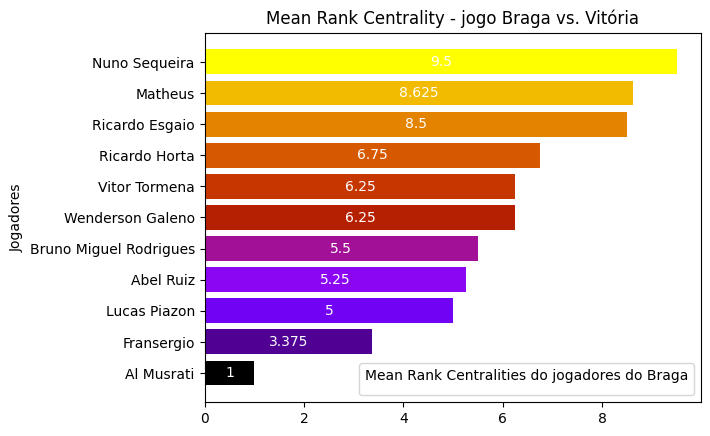

In [123]:
fig, ax = plt.subplots()

lista_jogadores = list(mean_rank_centralities_without_eigenvector(team = '372', game  = '2133362').keys())
lista_centralities = [v[0] for v in mean_rank_centralities_without_eigenvector(team = '372', game  = '2133362').values()]

cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(0, 1, 11)]
p = ax.barh(lista_jogadores, lista_centralities, color=colors)

ax.set_ylabel('Jogadores')
ax.set_title('Mean Rank Centrality - jogo Braga vs. Vitória')
ax.legend(title='Mean Rank Centralities do jogadores do Braga')
ax.bar_label(p, label_type='center',color='white')
plt.show()

In [86]:
# Calcula as Mean Rank Centralities para todos os jogos
mean_rank_centralities_all_matches_without_eigenvector(team = '372')

{'-': [5.5,
  5.5,
  8.125,
  6.25,
  3.875,
  4.125,
  9.25,
  5.375,
  6.25,
  1.25,
  5.0,
  6.125,
  2.25],
 'Al Musrati': [4.25,
  3.0,
  1.25,
  5.5,
  5.5,
  6.25,
  5.25,
  4.875,
  5.0,
  7.5,
  2.875,
  2.875,
  1.75,
  4.625,
  1.0,
  2.5,
  1.125,
  1.5,
  5.5,
  2.125,
  6.0,
  2.0],
 'André Castro': [1.0,
  1.625,
  4.625,
  5.125,
  1.75,
  2.625,
  4.25,
  2.25,
  6.375,
  1.375,
  5.125,
  7.0,
  5.0,
  2.5,
  4.125,
  2.0,
  2.5,
  1.25,
  3.5,
  1.5],
 'David Carmo': [5.75,
  6.5,
  6.125,
  8.0,
  8.5,
  2.875,
  3.875,
  6.125,
  3.375,
  3.25,
  3.0],
 'Fransergio': [10.0,
  9.375,
  2.625,
  5.625,
  5.625,
  3.625,
  9.625,
  4.375,
  6.375,
  3.75,
  6.875,
  4.5,
  5.625,
  3.5,
  2.625,
  2.625,
  3.375,
  1.625,
  2.625,
  7.25,
  7.75,
  4.125,
  3.75,
  6.25,
  5.625],
 'Matheus': [8.25,
  10.625,
  9.5,
  9.75,
  11.0,
  10.625,
  3.125,
  10.5,
  10.5,
  2.875,
  10.25,
  6.75,
  10.75,
  11.0,
  11.0,
  3.625,
  9.5,
  9.75,
  10.75,
  9.875,
  8.375,
 

In [84]:
# Define a média da medida de centralidade, de todos os jogadores do Braga, ao longo da época
mean_rank_centrality_season(mean_rank_centralities_all_matches_without_eigenvector(team='372'))

{'André Castro': 3.275,
 'Al Musrati': 3.7386363636363638,
 'Raúl Silva': 4.894230769230769,
 'Fransergio': 5.165,
 'David Carmo': 5.215909090909091,
 '-': 5.298076923076923,
 'Ricardo Esgaio': 5.34375,
 'Nuno Sequeira': 5.348958333333333,
 'Vitor Tormena': 5.83125,
 'Lucas Piazon': 6.0227272727272725,
 'Iuri Medeiros': 6.181818181818182,
 'Paulinho': 6.53125,
 'Wenderson Galeno': 6.758928571428571,
 'Ricardo Horta': 7.083333333333333,
 'Abel Ruiz': 8.0078125,
 'Matheus': 9.1796875}

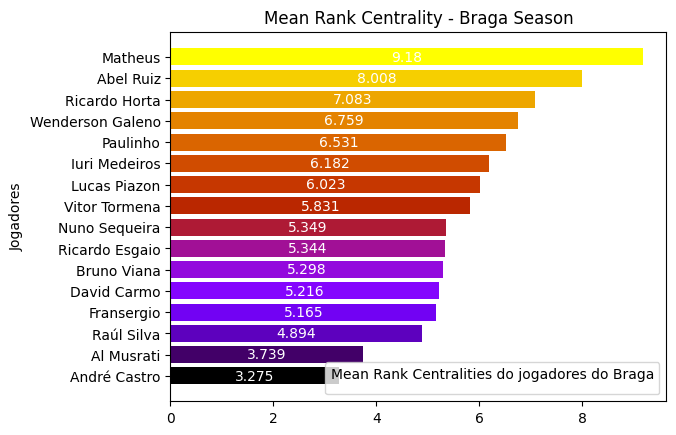

In [100]:
fig, ax = plt.subplots()

lista_jogadores = list(mean_rank_centrality_season(mean_rank_centralities_all_matches_without_eigenvector(team = '372')).keys())
lista_jogadores[5] = 'Bruno Viana'
lista_centralities = [round(v,3) for v in mean_rank_centrality_season(mean_rank_centralities_all_matches_without_eigenvector(team = '372')).values()]

cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(0, 1, 16)]
p = ax.barh(lista_jogadores, lista_centralities, color=colors)

ax.set_ylabel('Jogadores')
ax.set_title('Mean Rank Centrality - Braga Season')
ax.legend(title='Mean Rank Centralities do jogadores do Braga')
ax.bar_label(p, label_type='center',color='white')
plt.show()

In [13]:
# Define a média da mean rank Centrality para todos os jogadores, de todas as equipas, ao longo da época
# Rashid é o jogador marcado com '-' do Santa Clara
for id_team in all_match_events['team_id'].unique():
  print(mean_rank_centrality_season(mean_rank_centralities_all_matches_without_eigenvector(team=id_team)))

{'-': 2.3875, 'Hidemasa Morita': 3.8125, 'Nené': 4.340909090909091, 'Anderson Carvalho': 4.636363636363637, 'Mikel Villanueva': 4.975961538461538, 'Lincoln': 4.978260869565218, 'Mansur': 5.364130434782608, 'Ukra': 5.6875, 'Crysan': 5.767857142857143, 'Rafael Ramos': 6.341346153846154, 'João Afonso': 6.375, 'Fábio Cardoso': 6.645, 'Allano': 6.6875, 'Carlos Junior': 6.915178571428571, 'Marco Pereira': 8.545833333333333}
{'Rafik Guitane': 4.340277777777778, 'René': 4.3478260869565215, 'Franck-Yves Bambock': 4.368055555555555, 'Pedro Pelágio': 4.493055555555555, 'Zainadine Júnior': 4.65625, 'Léo Andrade': 4.833333333333333, 'Marcelo Hermes': 4.8352272727272725, 'Lucas Áfrico': 5.316666666666666, 'Fabio China': 5.625, 'Jean': 5.961956521739131, 'Claudio Winck': 6.008928571428571, 'Edgar Costa': 6.291666666666667, 'Jorge Correa': 6.458333333333333, 'Joel Tagueu': 6.824074074074074, 'Rodrigo Pinho': 7.586538461538462, 'Ali Alipour': 8.806818181818182, 'Amir Abedzadeh': 9.051724137931034}
{'Pê

In [14]:
################################################### HOME #########################################################

In [15]:
# Calcula as Mean Rank Centralities de todos os jogadores do Braga para os jogos em casa
mean_rank_centralities_all_home_matches_without_eigenvector('372')

{'-': [5.5, 3.875, 4.125, 5.375, 1.25, 5.0, 2.25],
 'Al Musrati': [3.0, 1.25, 4.875, 7.5, 2.875, 1.0, 2.5, 1.5, 6.0],
 'André Horta': [4.75, 2.0],
 'David Carmo': [6.5, 8.5, 2.875, 3.25, 3.0],
 'Francisco Moura': [7.875],
 'Matheus': [10.625,
  11.0,
  10.625,
  10.5,
  2.875,
  10.75,
  3.625,
  9.5,
  10.75,
  8.625,
  4.75,
  10.125,
  11.0,
  11.0,
  10.25,
  9.75],
 'Nuno Sequeira': [3.25,
  3.5,
  6.375,
  4.25,
  5.875,
  5.125,
  9.5,
  5.125,
  6.375,
  2.375,
  8.625,
  8.375],
 'Paulinho': [5.5, 2.875, 8.375, 5.25, 8.875, 9.5],
 'Ricardo Esgaio': [1.75,
  2.25,
  6.125,
  6.125,
  7.625,
  3.0,
  7.125,
  6.875,
  6.5,
  5.0,
  8.5,
  8.5,
  6.375,
  2.375,
  5.25,
  6.0,
  2.625],
 'Ricardo Horta': [7.875,
  9.0,
  8.75,
  5.625,
  5.25,
  5.625,
  5.0,
  4.625,
  6.75,
  9.375,
  7.25,
  6.75,
  7.0,
  7.875,
  5.5],
 'Fransergio': [9.375,
  5.625,
  3.625,
  9.625,
  3.75,
  5.625,
  3.375,
  1.625,
  2.625,
  7.75,
  4.125,
  3.75,
  5.625],
 'André Castro': [5.125, 1.75

In [16]:
# Calcula as médias das Mean Rank Centralities dos jogadores do Braga para os jogos em casa
mean_rank_centrality_season_home(mean_rank_centralities_all_home_matches_without_eigenvector('372'))

{'Al Musrati': 3.388888888888889,
 'André Castro': 3.775,
 '-': 3.9107142857142856,
 'Raúl Silva': 4.410714285714286,
 'David Carmo': 4.825,
 'Fransergio': 5.115384615384615,
 'Ricardo Esgaio': 5.411764705882353,
 'Lucas Piazon': 5.4375,
 'Nuno Sequeira': 5.729166666666667,
 'Vitor Tormena': 6.181818181818182,
 'Iuri Medeiros': 6.291666666666667,
 'Paulinho': 6.729166666666667,
 'Ricardo Horta': 6.816666666666666,
 'Wenderson Galeno': 7.223214285714286,
 'Abel Ruiz': 8.375,
 'Matheus': 9.109375}

In [17]:
# Define a média da mean rank Centrality para todos os jogadores, de todas as equipas, ao longo da época, para os jogos em casa
for id_team in all_match_events['team_id'].unique():
  print(mean_rank_centrality_season_home(mean_rank_centralities_all_home_matches_without_eigenvector(team=id_team)))

{'Nené': 3.75, 'Hidemasa Morita': 4.0625, 'Anderson Carvalho': 4.3625, 'Mikel Villanueva': 4.778846153846154, 'Mansur': 5.318181818181818, 'Lincoln': 5.420454545454546, 'Rafael Ramos': 5.8522727272727275, 'Crysan': 6.05, 'Allano': 6.535714285714286, 'Fábio Cardoso': 6.708333333333333, 'Carlos Junior': 6.990384615384615, 'Marco Pereira': 8.625}
{'René': 3.3365384615384617, 'Franck-Yves Bambock': 3.9464285714285716, 'Rafik Guitane': 4.097222222222222, 'Zainadine Júnior': 4.383928571428571, 'Marcelo Hermes': 4.659090909090909, 'Pedro Pelágio': 4.6875, 'Léo Andrade': 4.903846153846154, 'Fabio China': 5.375, 'Lucas Áfrico': 5.666666666666667, 'Jorge Correa': 6.375, 'Claudio Winck': 6.419642857142857, 'Jean': 6.430555555555555, 'Rodrigo Pinho': 6.535714285714286, 'Edgar Costa': 6.84375, 'Joel Tagueu': 7.276785714285714, 'Ali Alipour': 9.0625, 'Amir Abedzadeh': 9.275}
{'Gustavo Assunção': 3.0568181818181817, 'Pêpê': 3.109375, 'Diogo Queirós': 3.4107142857142856, 'Joaquín Pereyra': 4.25, 'Patr

In [18]:
################################# AWAY ###############################

In [19]:
# Calcula as Mean Rank Centralities de todos os jogadores do Braga para os jogos fora
mean_rank_centralities_all_away_matches_without_eigenvector('372')

{'-': [5.5, 8.125, 6.25, 9.25, 6.25, 6.125],
 'Al Musrati': [4.25,
  5.5,
  5.5,
  6.25,
  5.25,
  5.0,
  2.875,
  1.75,
  4.625,
  1.125,
  5.5,
  2.125,
  2.0],
 'André Castro': [1.0, 1.625, 4.625, 2.625, 2.25, 1.375, 7.0, 2.5, 1.25, 3.5],
 'David Carmo': [5.75, 6.125, 8.0, 3.875, 6.125, 3.375],
 'Fransergio': [10.0,
  2.625,
  5.625,
  4.375,
  6.375,
  6.875,
  4.5,
  3.5,
  2.625,
  2.625,
  7.25,
  6.25],
 'Matheus': [8.25,
  9.5,
  9.75,
  3.125,
  10.5,
  10.25,
  6.75,
  11.0,
  11.0,
  9.75,
  9.875,
  8.375,
  9.5,
  9.5,
  9.875,
  11.0],
 'Nuno Sequeira': [5.75,
  7.375,
  2.875,
  5.75,
  4.125,
  4.875,
  6.375,
  4.25,
  4.75,
  3.0,
  3.875,
  6.625],
 'Ricardo Esgaio': [3.5,
  5.25,
  3.25,
  9.0,
  3.625,
  5.5,
  7.875,
  2.5,
  5.75,
  5.125,
  2.875,
  4.5,
  6.0,
  6.0,
  8.25],
 'Ricardo Horta': [4.125,
  9.0,
  8.25,
  10.125,
  9.25,
  2.875,
  9.75,
  9.25,
  5.25,
  9.5,
  2.625,
  7.75,
  8.25,
  9.375,
  4.875],
 'Abel Ruiz': [10.5, 6.625, 6.375, 8.75, 9.7

In [20]:
# Calcula as médias das Mean Rank Centralities dos jogadores do Braga para os jogos fora
mean_rank_centrality_season_away(mean_rank_centralities_all_away_matches_without_eigenvector('372'))

{'André Castro': 2.775,
 'Al Musrati': 3.980769230769231,
 'João Novais': 4.666666666666667,
 'Nuno Sequeira': 4.96875,
 'Fransergio': 5.21875,
 'Ricardo Esgaio': 5.266666666666667,
 'Vitor Tormena': 5.402777777777778,
 'Bruno Miguel Rodrigues': 5.425,
 'Raúl Silva': 5.458333333333333,
 'David Carmo': 5.541666666666667,
 'Iuri Medeiros': 6.05,
 'Cristián Borja': 6.175,
 'Wenderson Galeno': 6.294642857142857,
 'Paulinho': 6.333333333333333,
 'Lucas Piazon': 6.725,
 '-': 6.916666666666667,
 'Ricardo Horta': 7.35,
 'Abel Ruiz': 7.722222222222222,
 'Matheus': 9.25}

In [21]:
# Define a média da mean rank Centrality para todos os jogadores, de todas as equipas, ao longo da época, para os jogos fora
for id_team in all_match_events['team_id'].unique():
  print(mean_rank_centrality_season_away(mean_rank_centralities_all_away_matches_without_eigenvector(team=id_team)))

{'-': 1.8958333333333333, 'Hidemasa Morita': 3.6125, 'Lincoln': 4.572916666666667, 'Anderson Carvalho': 4.864583333333333, 'Nené': 5.05, 'Mikel Villanueva': 5.173076923076923, 'Mansur': 5.40625, 'Ukra': 5.464285714285714, 'Crysan': 5.611111111111111, 'João Afonso': 5.6875, 'Fábio Cardoso': 6.586538461538462, 'Rafael Ramos': 6.7, 'Carlos Junior': 6.85, 'Allano': 6.9, 'Diogo Salomão': 6.9375, 'Marco Pereira': 8.485294117647058}
{'Pedro Pelágio': 4.25, 'Rafik Guitane': 4.583333333333333, 'Franck-Yves Bambock': 4.636363636363637, 'Léo Andrade': 4.71875, 'Zainadine Júnior': 4.928571428571429, 'Marcelo Hermes': 5.011363636363637, 'Lucas Áfrico': 5.083333333333333, 'Claudio Winck': 5.598214285714286, 'Edgar Costa': 5.660714285714286, 'Jean': 5.660714285714286, 'René': 5.6625, 'Fabio China': 5.925, 'Joel Tagueu': 6.336538461538462, 'Jorge Correa': 6.53125, 'Andreas Karo': 7.15, 'Ali Alipour': 8.5, 'Amir Abedzadeh': 8.8125, 'Rodrigo Pinho': 8.8125}
{'Pêpê': 2.1805555555555554, 'Gustavo Assunção

In [22]:
########################### TOP ###########################################

In [23]:
# Calcula as Mean Rank Centralities de todos os jogadores do Braga para os TOP matches
mean_rank_centralities_all_top_matches_without_eigenvector('372')

{'-': [5.5, 9.25],
 'Al Musrati': [4.25, 5.5, 5.25, 7.5, 2.5],
 'André Castro': [1.0, 2.625, 2.0],
 'David Carmo': [5.75, 3.0],
 'Fransergio': [10.0, 6.375, 5.625, 1.625, 4.125],
 'Matheus': [8.25, 3.125, 6.75, 9.5, 4.75, 11.0],
 'Nuno Sequeira': [5.75, 5.75, 6.375, 2.375],
 'Ricardo Esgaio': [3.5, 9.0, 7.875, 6.5, 8.5, 5.25],
 'Ricardo Horta': [4.125, 2.875, 5.0, 9.375, 7.0],
 'Abel Ruiz': [10.5, 10.0, 10.0, 7.875],
 'Raúl Silva': [7.375, 7.125, 4.875, 4.875],
 'Paulinho': [3.5, 4.75],
 'Vitor Tormena': [5.875, 4.0, 6.25, 6.625],
 'Wenderson Galeno': [4.75, 10.875, 7.5, 5.25, 6.75],
 'Francisco Moura': [9.0],
 'Iuri Medeiros': [7.625],
 'João Novais': [1.75, 2.5],
 'Rolando': [6.0],
 'Cristián Borja': [5.625],
 'Lucas Piazon': [5.125],
 'Bruno Miguel Rodrigues': [7.0],
 'Nicolás Gaitán': [8.125]}

In [24]:
# Calcula as médias das Mean Rank Centralities dos jogadores do Braga para os TOP matches
mean_rank_centrality_season_top(mean_rank_centralities_all_top_matches_without_eigenvector('372'))

{'André Castro': 1.875,
 'João Novais': 2.125,
 'Paulinho': 4.125,
 'David Carmo': 4.375,
 'Al Musrati': 5.0,
 'Nuno Sequeira': 5.0625,
 'Fransergio': 5.55,
 'Ricardo Horta': 5.675,
 'Vitor Tormena': 5.6875,
 'Raúl Silva': 6.0625,
 'Ricardo Esgaio': 6.770833333333333,
 'Wenderson Galeno': 7.025,
 'Matheus': 7.229166666666667,
 '-': 7.375,
 'Abel Ruiz': 9.59375}

In [25]:
# Define a média da mean rank Centrality para todos os jogadores, de todas as equipas, ao longo da época, para os TOP matches
for id_team in all_match_events['team_id'].unique():
  print(mean_rank_centrality_season_top(mean_rank_centralities_all_top_matches_without_eigenvector(team=id_team)))

{'Diogo Salomão': 3.5, '-': 3.75, 'Hidemasa Morita': 4.03125, 'Lincoln': 4.520833333333333, 'Mikel Villanueva': 4.9375, 'Rafael Ramos': 5.375, 'Pierre Sagna': 5.4375, 'Crysan': 5.53125, 'Carlos Junior': 5.75, 'Mansur': 5.979166666666667, 'Anderson Carvalho': 6.041666666666667, 'Allano': 6.3125, 'Jean Patric': 7.0, 'Nené': 7.125, 'João Afonso': 7.35, 'Marco Pereira': 7.732142857142857, 'Fábio Cardoso': 7.96875, 'Ukra': 8.0625}
{'Franck-Yves Bambock': 3.21875, 'Rafik Guitane': 3.5, 'René': 4.214285714285714, 'Pedro Pelágio': 4.541666666666667, 'Marcelo Hermes': 4.625, 'Rodrigo Pinho': 4.8125, 'Joel Tagueu': 5.145833333333333, 'Lucas Áfrico': 5.4375, 'Léo Andrade': 5.8, 'Edgar Costa': 5.916666666666667, 'Jorge Correa': 6.0625, 'Zainadine Júnior': 6.083333333333333, 'Claudio Winck': 6.5, 'Jean': 6.571428571428571, 'Andreas Karo': 7.875, 'Rúben Macedo': 8.25, 'Amir Abedzadeh': 8.6875, 'Charles': 9.5, 'Ali Alipour': 10.041666666666666}
{'Pêpê': 2.125, 'Joaquín Pereyra': 2.7083333333333335, '

In [26]:
############################################################### Own half

In [27]:
# Calcula as Mean Rank Centralities de todos os jogadores do Braga, no próprio meio-campo
mean_rank_centralities_own_half(team = '372', game  = '2133362')

{'Al Musrati': [1.5],
 'Fransergio': [4.375],
 'Wenderson Galeno': [5.0],
 'Lucas Piazon': [5.5],
 'Bruno Miguel Rodrigues': [5.625],
 'Ricardo Horta': [6.5],
 'Abel Ruiz': [6.75],
 'Vitor Tormena': [7.125],
 'Ricardo Esgaio': [7.25],
 'Nuno Sequeira': [8.125],
 'Matheus': [8.25]}

In [28]:
# Calcula as médias das Mean Rank Centralities dos jogadores do Braga no próprio meio-campo
mean_rank_centralities_all_matches_own_half('372')

{'-': [4.0,
  4.875,
  7.125,
  4.0,
  1.0,
  2.125,
  9.625,
  6.625,
  3.75,
  1.125,
  5.375,
  4.5,
  1.75],
 'Al Musrati': [2.125,
  3.875,
  2.875,
  4.625,
  7.0,
  8.375,
  5.25,
  6.25,
  3.0,
  6.75,
  2.375,
  2.75,
  2.25,
  3.125,
  1.5,
  4.625,
  1.5,
  1.25,
  2.25,
  4.625,
  4.625,
  3.125],
 'André Castro': [3.125,
  1.5,
  4.625,
  8.625,
  1.625,
  2.125,
  2.5,
  5.25,
  9.0,
  1.625,
  6.0,
  6.875,
  4.0,
  3.75,
  3.375,
  2.125,
  3.875,
  3.875,
  3.375,
  4.375],
 'David Carmo': [3.375,
  2.0,
  5.25,
  5.375,
  3.625,
  4.25,
  1.875,
  3.875,
  2.5,
  3.875,
  2.0],
 'Fransergio': [10.0,
  2.25,
  7.875,
  4.875,
  3.375,
  8.75,
  6.75,
  5.0,
  1.375,
  9.125,
  4.875,
  6.5,
  5.25,
  1.75,
  1.375,
  4.375,
  1.5,
  3.5,
  8.0,
  7.5,
  3.125,
  4.75,
  7.5,
  10.0],
 'Matheus': [6.5,
  8.125,
  5.625,
  7.375,
  9.625,
  9.125,
  2.75,
  9.0,
  8.375,
  2.875,
  6.875,
  3.875,
  7.875,
  8.25,
  10.625,
  3.25,
  6.5,
  5.875,
  6.5,
  6.875,
  7.375

In [29]:
# Define a média da medida de centralidade, de todos os jogadores do Braga, ao longo da época
mean_rank_centrality_season_own_half(mean_rank_centralities_all_matches_own_half(team='372'))

{'Raúl Silva': 3.298076923076923,
 'David Carmo': 3.4545454545454546,
 'Al Musrati': 3.8238636363636362,
 'André Castro': 4.08125,
 '-': 4.298076923076923,
 'Vitor Tormena': 4.7,
 'Nuno Sequeira': 4.776041666666667,
 'Fransergio': 5.390625,
 'Ricardo Esgaio': 6.28515625,
 'Matheus': 6.921875,
 'Paulinho': 7.0227272727272725,
 'Wenderson Galeno': 7.356481481481482,
 'Lucas Piazon': 7.409090909090909,
 'Iuri Medeiros': 7.886363636363637,
 'Ricardo Horta': 8.2,
 'Abel Ruiz': 8.708333333333334}

In [30]:
# Define a média da mean rank Centrality para todos os jogadores, de todas as equipas, ao longo da época, no próprio meio-campo
# Rashid - Santa Clara
for id_team in all_match_events['team_id'].unique():
  print(mean_rank_centrality_season_own_half(mean_rank_centralities_all_matches_own_half(team=id_team)))

{'Mikel Villanueva': 3.7548076923076925, '-': 3.9375, 'Nené': 4.318181818181818, 'João Afonso': 4.446428571428571, 'Hidemasa Morita': 4.493055555555555, 'Anderson Carvalho': 5.073863636363637, 'Mansur': 5.086956521739131, 'Fábio Cardoso': 5.3, 'Lincoln': 5.771739130434782, 'Crysan': 6.3375, 'Marco Pereira': 6.479166666666667, 'Rafael Ramos': 6.831730769230769, 'Ukra': 6.8625, 'Carlos Junior': 7.32, 'Allano': 7.46875}
{'Zainadine Júnior': 3.6651785714285716, 'René': 3.8097826086956523, 'Franck-Yves Bambock': 3.8819444444444446, 'Léo Andrade': 4.071428571428571, 'Rafik Guitane': 5.229166666666667, 'Lucas Áfrico': 5.45, 'Pedro Pelágio': 5.458333333333333, 'Jean': 5.543478260869565, 'Fabio China': 5.545454545454546, 'Claudio Winck': 6.098214285714286, 'Marcelo Hermes': 6.2727272727272725, 'Jorge Correa': 6.892857142857143, 'Edgar Costa': 6.9, 'Amir Abedzadeh': 7.112068965517241, 'Joel Tagueu': 7.380208333333333, 'Rodrigo Pinho': 8.479166666666666, 'Ali Alipour': 9.647727272727273}
{'Gustav

In [31]:
# Visualiza a redes de passes no próprio meio-campo
visualize_pass_network_own_half(team_id = '372', game_id = '2133362')

Output hidden; open in https://colab.research.google.com to view.

In [32]:
###################################################################### Opposite half

In [33]:
# Calcula as Mean Rank Centralities de todos os jogadores do Braga, no meio-campo adversário
mean_rank_centralities_opposite_half(team = '372', game  = '2133362')

{'Al Musrati': [1.75],
 'Wenderson Galeno': [3.0],
 'Lucas Piazon': [3.375],
 'Fransergio': [3.5],
 'Abel Ruiz': [4.875],
 'Ricardo Horta': [6.625],
 'Ricardo Esgaio': [6.875],
 'Vitor Tormena': [7.125],
 'Nuno Sequeira': [7.875],
 'Matheus': [10.5],
 'Bruno Miguel Rodrigues': [10.5]}

In [34]:
# Calcula as médias das Mean Rank Centralities dos jogadores do Braga no meio-campo adversário
mean_rank_centralities_all_matches_opposite_half('372')

{'-': [5.5,
  5.5,
  8.125,
  6.25,
  3.875,
  4.125,
  9.25,
  5.375,
  6.25,
  1.25,
  5.0,
  6.125,
  2.25],
 'Al Musrati': [4.25,
  3.0,
  1.25,
  5.5,
  5.5,
  6.25,
  5.25,
  4.875,
  5.0,
  7.5,
  2.875,
  2.875,
  1.75,
  4.625,
  1.0,
  2.5,
  1.125,
  1.5,
  5.5,
  2.125,
  6.0,
  2.0],
 'André Castro': [1.0,
  1.625,
  4.625,
  5.125,
  1.75,
  2.625,
  4.25,
  2.25,
  6.375,
  1.375,
  5.125,
  7.0,
  5.0,
  2.5,
  4.125,
  2.0,
  2.5,
  1.25,
  3.5,
  1.5],
 'David Carmo': [5.75,
  6.5,
  6.125,
  8.0,
  8.5,
  2.875,
  3.875,
  6.125,
  3.375,
  3.25,
  3.0],
 'Fransergio': [10.0,
  9.375,
  2.625,
  5.625,
  5.625,
  3.625,
  9.625,
  4.375,
  6.375,
  3.75,
  6.875,
  4.5,
  5.625,
  3.5,
  2.625,
  2.625,
  3.375,
  1.625,
  2.625,
  7.25,
  7.75,
  4.125,
  3.75,
  6.25,
  5.625],
 'Matheus': [8.25,
  10.625,
  9.5,
  9.75,
  11.0,
  10.625,
  3.125,
  10.5,
  10.5,
  2.875,
  10.25,
  6.75,
  10.75,
  11.0,
  11.0,
  3.625,
  9.5,
  9.75,
  10.75,
  9.875,
  8.375,
 

In [35]:
# Define a média da medida de centralidade, de todos os jogadores do Braga, ao longo da época, no meio-campo adversário
mean_rank_centrality_season_opposite_half(mean_rank_centralities_all_matches_opposite_half(team='372'))

{'André Castro': 3.275,
 'Al Musrati': 3.7386363636363638,
 'Raúl Silva': 4.894230769230769,
 'Fransergio': 5.165,
 'David Carmo': 5.215909090909091,
 '-': 5.298076923076923,
 'Ricardo Esgaio': 5.34375,
 'Nuno Sequeira': 5.348958333333333,
 'Vitor Tormena': 5.83125,
 'Lucas Piazon': 6.0227272727272725,
 'Iuri Medeiros': 6.181818181818182,
 'Paulinho': 6.53125,
 'Wenderson Galeno': 6.758928571428571,
 'Ricardo Horta': 7.083333333333333,
 'Abel Ruiz': 8.0078125,
 'Matheus': 9.1796875}

In [36]:
# Define a média da mean rank Centrality para todos os jogadores, de todas as equipas, ao longo da época, no meio-campo adversário
# Rashid - Santa Clara
for id_team in all_match_events['team_id'].unique():
  print(mean_rank_centrality_season_opposite_half(mean_rank_centralities_all_matches_opposite_half(team=id_team)))

{'-': 2.3875, 'Hidemasa Morita': 3.8125, 'Nené': 4.340909090909091, 'Anderson Carvalho': 4.636363636363637, 'Mikel Villanueva': 4.975961538461538, 'Lincoln': 4.978260869565218, 'Mansur': 5.364130434782608, 'Ukra': 5.6875, 'Crysan': 5.767857142857143, 'Rafael Ramos': 6.341346153846154, 'João Afonso': 6.375, 'Fábio Cardoso': 6.645, 'Allano': 6.6875, 'Carlos Junior': 6.915178571428571, 'Marco Pereira': 8.545833333333333}
{'Rafik Guitane': 4.340277777777778, 'René': 4.3478260869565215, 'Franck-Yves Bambock': 4.368055555555555, 'Pedro Pelágio': 4.493055555555555, 'Zainadine Júnior': 4.65625, 'Léo Andrade': 4.833333333333333, 'Marcelo Hermes': 4.8352272727272725, 'Lucas Áfrico': 5.316666666666666, 'Fabio China': 5.625, 'Jean': 5.961956521739131, 'Claudio Winck': 6.008928571428571, 'Edgar Costa': 6.291666666666667, 'Jorge Correa': 6.458333333333333, 'Joel Tagueu': 6.824074074074074, 'Rodrigo Pinho': 7.586538461538462, 'Ali Alipour': 8.806818181818182, 'Amir Abedzadeh': 9.051724137931034}
{'Pê

In [37]:
# Visualiza a redes de passes no meio-campo adversário
visualize_pass_network_opposite_half(team_id = '372', game_id = '2133362')

Output hidden; open in https://colab.research.google.com to view.

In [38]:
#####################################################################################################################